## Punto 1. a

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from mpl_toolkits.mplot3d import axes3d

In [149]:
A = np.array([[2,-1],[1,2],[1,1]])
b = np.array([[2],[1],[4]])

In [150]:
AT = np.transpose(A)

In [151]:
ATb = np.dot(AT,b)

In [152]:
ATA = np.dot(AT,A)

In [153]:
InvATA = np.linalg.inv(ATA)

In [154]:
mc = np.dot(InvATA,ATb)

In [155]:
print(mc)

[[1.42857143]
 [0.42857143]]


In [156]:
x=np.arange(-5,10)

In [157]:
y = 2*x-2
y = -(1/2)*x + (1/2)
y = 4 -x

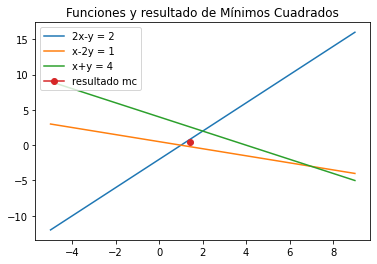

In [158]:
plt.plot(x,y1, label = "2x-y = 2")
plt.plot(x,y2, label = "x-2y = 1")
plt.plot(x,y3, label = "x+y = 4")
plt.plot(mc[0],mc[1],marker ="o",label = "resultado mc")
plt.title("Funciones y resultado de Mínimos Cuadrados")
plt.legend(loc = "upper left")

### Interpretación
El punto rojo refleja los valores del vector x que minimizan la distancia entre Ax y b (i.e. los valores del vector x que hacen que Ax sea la proyección de b sobre el espacio columna de a, considerando que esa proyección es el vector perteneciente al espacio columna de a más cercano a b). 

## Punto 1. b

In [159]:
espacio = np.arange(-5,5,0.3)
minimo = 1000000000
resultadofinal = 0

In [160]:
for i in espacio:
    for j in espacio:
        vector = np.array([[i],[j]])
        resultado = np.dot(A,vector)-b
        distancia = np.linalg.norm(resultado) 
        if distancia < minimo:
            minimo = distancia
            resultadofinal = vector
print(resultadofinal)

[[1.3]
 [0.4]]


In [188]:
x=np.array([])
y=np.array([])
z=np.array([])

for i in espacio:
    for j in espacio:
        vector = np.array([[i],[j]])
        resultado = np.dot(A,vector)-b
        distancia = np.linalg.norm(resultado)
        x=np.append(x,i)
        y=np.append(y,j)
        z=np.append(z,distancia)
        
x=x.reshape(1,-1)
y=y.reshape(1,-1)
z=z.reshape(1,-1)



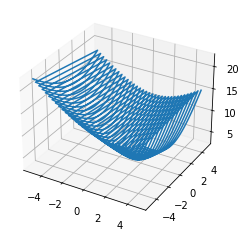

In [189]:
fig = plt.figure()

ax1 = fig.add_subplot(111,projection='3d')

ax1.plot_wireframe(x, y, z)
plt.show()

## Punto 7. a

In [248]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import os.path as path
import wget
import pandas as pd
import math

In [226]:
url = 'https://raw.githubusercontent.com/asegura4488/Database/main/MetodosComputacionalesReforma/Sigmoid.csv'
Path_ = wget.download(url)

In [236]:
datacsv = pd.read_csv(Path_, header=None, skiprows=1)
data = np.array(datacsv)

In [272]:
x = data[:,0]
y = data[:,1]
pmts = ([1,1,1]) 

def M(x,pmts):
    M =(pmts[0])/(pmts[1]+ math.e**(-(pmts[2])*x ))
    return M
    


## Punto 7. b

In [283]:

def getmetrica(M,pmts):
    
    metrica = 0
    conteo = 0
    
    for i in x:
        metricai = (y[conteo]-M(i,pmts))**2
        metrica += metricai
        conteo +=1

    print(metrica)


In [288]:
def GetVectorF(metrica,pmts):
    
    dim = len(G)
    
    v = np.zeros(dim)
    
    for i in range(dim):
        v[i] = M[i](pmts[0],pmts[1],pmts[2])
        
    return v

In [289]:
def GetJacobian(M,pmts,h=1e-6):
    
    dim = len(M)
    
    J = np.zeros((dim,dim))
    
    for i in range(dim):
        J[i,0] = (  M[i](r[0]+h,r[1],r[2]) - M[i](r[0]-h,r[1],r[2]) )/(2*h)
        J[i,1] = (  M[i](r[0],r[1]+h,r[2]) - M[i](r[0],r[1]-h,r[2]) )/(2*h)
        J[i,2] = (  M[i](r[0],r[1],r[2]+h) - M[i](r[0],r[1],r[2]-h) )/(2*h)
        
    return J.T

In [290]:
def GetSolve(M,pmts,ta=1e-3,intmax=int(1e4),error=1e-2):
    
    d = 1
    it = 0
    Vector_F = np.array([])
    
    R_vector = np.array(pmts)
    
    while d > error and it < intmax:
        
        CurrentF = getmetrica(M,pmts)
        
        J = GetJacobian(M,pmts)
        
        GVector = GetVectorF(M,pmts)
        
        #Machine Learning
        pmts -= lr*np.dot(J,GVector) 
        
        R_vector = np.vstack((R_vector,r))
        
        NewF = getmetrica(M,pmts)
        
        
        Vector_F = np.append(Vector_F,NewF)
        
        d = np.abs( CurrentF - NewF )/NewF
        
        
        if it%500 == 0:
            
            #print(it,d)
            clear_output(wait=True)
            GetFig(Vector_F,R_vector,it)
            time.sleep(0.01)
            
        it += 1
        
    if d < error:
        print(' Entrenamiento completo ', d, 'iteraciones', it)
        
    if it == intmax:
        print(' Entrenamiento no completado ')
        
    return r,it,Vector_F,R_vector

# Punto 8. a

In [268]:
A = np.array([[3,1,-1],[1,2,0],[0,1,2],[1,1,-1]])
b = np.array([[-3],[-3],[8],[9]])

In [270]:
AT = np.transpose(A)
ATb = np.dot(AT,b)
ATA = np.dot(AT,A)
InvATA = np.linalg.inv(ATA)
mc = np.dot(InvATA,ATb)
proyeccion = np.dot(A,mc)

In [271]:
print(proyeccion)

[[-2.0000000e+00]
 [ 3.0000000e+00]
 [ 4.0000000e+00]
 [ 4.4408921e-16]]
